In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


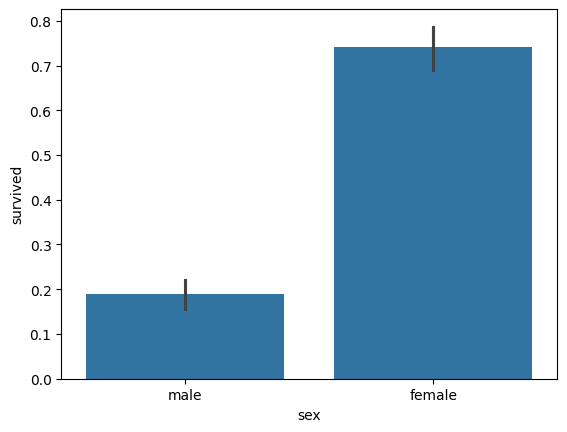

In [5]:
sns.barplot(data = df,x = 'sex' , y = 'survived')
plt.show()

In [6]:
df.sex.value_counts()

sex
male      577
female    314
Name: count, dtype: int64

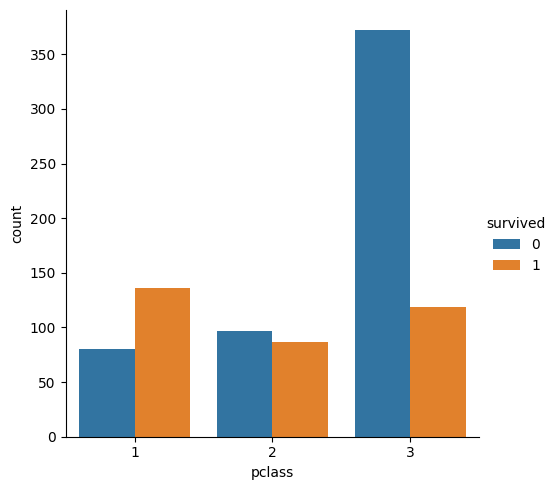

In [9]:
sns.catplot(data = df, x='pclass',hue = 'survived',kind='count')
plt.show()

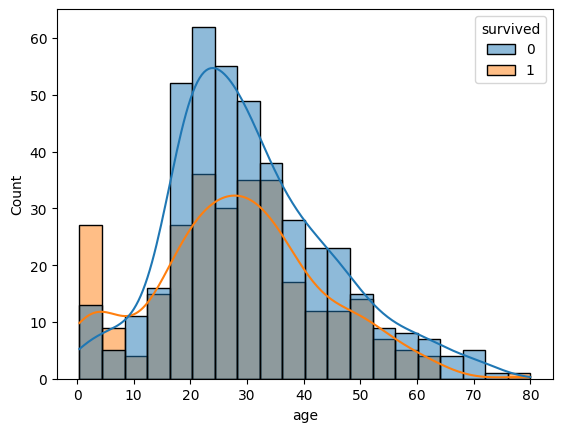

In [11]:
sns.histplot(data=df , x = 'age',kde = True,hue = 'survived')
plt.show()

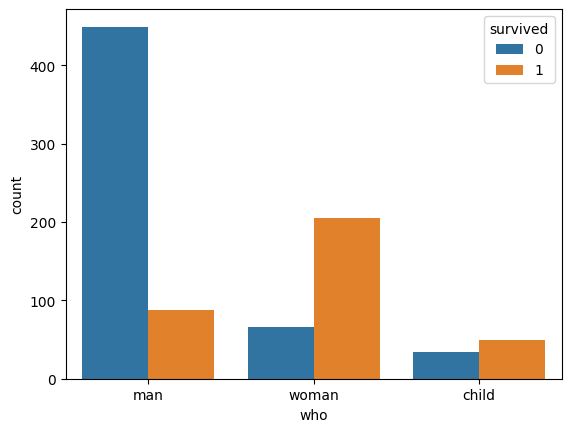

In [13]:
sns.countplot(data = df, x='who',hue = 'survived')
plt.show()

In [14]:
#feature enginering

In [15]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [18]:
df.shape

(891, 15)

In [19]:
df = df.drop(["deck","embark_town","alive"],axis = 1 )

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


In [21]:
df.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [22]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [24]:
df.embarked.value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [25]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [26]:
df.sex.value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [31]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [33]:
df["adult_male"] = df["adult_male"].astype(int)

df["alone"] = df["alone"].astype(int)

In [34]:
X = df.drop("survived",axis = 1)
y = df['survived']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['sex', 'class', 'who','embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [37]:

encoded_cols = preprocessor.get_feature_names_out()

In [38]:
X_train = pd.DataFrame(X_train, columns = encoded_cols)
X_test = pd.DataFrame(X_test, columns = encoded_cols)
X_train.head()

,cat__sex_male,cat__class_Second,cat__class_Third,cat__who_man,cat__who_woman,cat__embarked_Q,cat__embarked_S,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,27.0,0.0,0.0,7.8958,1.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,17.0,0.0,0.0,10.5000,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,28.0,0.0,0.0,0.0000,1.0,1.0
3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,26.0,0.0,0.0,8.0500,1.0,1.0
4,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,43.0,0.0,0.0,8.0500,1.0,1.0


DOWLOAND LIBRARY TO THIS ENV

In [46]:
#import sys
#!{sys.executable} -m pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)


In [47]:
import lightgbm as lgb

In [48]:

from sklearn.metrics import classification_report, confusion_matrix

In [49]:
clf = lgb.LGBMClassifier(verbosity=-1)
clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [50]:
y_pred = clf.predict(X_test)

In [51]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       128
           1       0.75      0.76      0.75        95

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.79      0.79      0.79       223

[[104  24]
 [ 23  72]]


In [ ]:
#Vacib Qeyd hansi columnun nə qədər vacib olduğunu tapmaq

In [52]:
importances = clf.feature_importances_

feature_names = X_train.columns
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importance)

                  Feature  Importance
11        remainder__fare        1132
8          remainder__age         865
6         cat__embarked_S          81
10       remainder__parch          77
9        remainder__sibsp          65
0           cat__sex_male          60
2        cat__class_Third          51
13       remainder__alone          41
1       cat__class_Second          41
4          cat__who_woman          36
5         cat__embarked_Q          35
3            cat__who_man          19
7       remainder__pclass          10
12  remainder__adult_male           0


In [54]:
import sys
!{sys.executable} -m pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 813.3 kB/s eta 0:00:00MB/s eta 0:00:01
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.0 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 8.0 MB/s eta 0:00:00m eta 0:00:010:01:01m
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)


/home/bayazit/ml_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/bayazit/ml_env/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


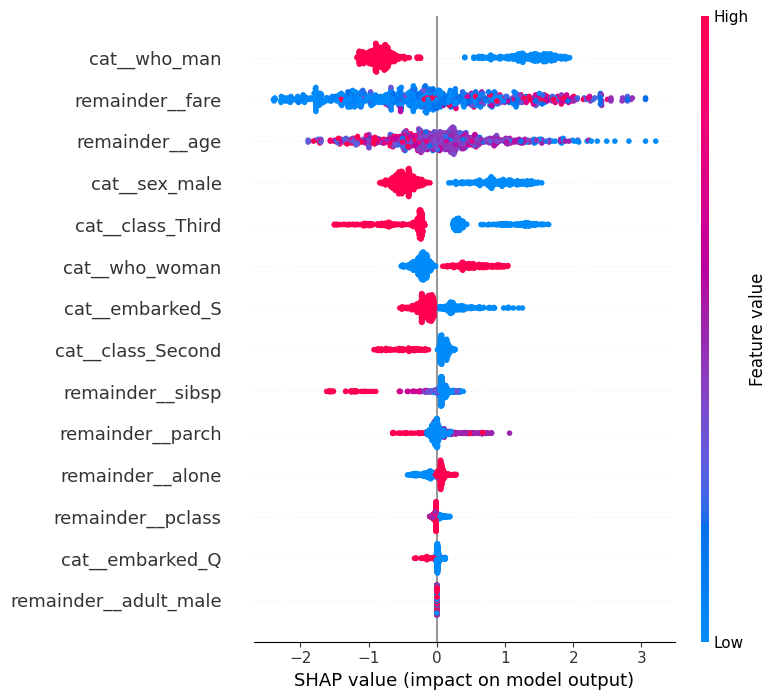

In [55]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

In [56]:


shap_df = pd.DataFrame(shap_values, columns=X_train.columns)
print(shap_df.head())

   cat__sex_male  cat__class_Second  cat__class_Third  cat__who_man  \
0      -0.494154           0.140315         -0.235277     -0.867160   
1       1.067896          -0.322049          1.078549      1.738011   
2      -0.655060           0.105676          0.264864     -1.130975   
3      -0.387534           0.160692         -0.280492     -0.657320   
4      -0.329126           0.115178         -0.251187     -0.717687   

   cat__who_woman  cat__embarked_Q  cat__embarked_S  remainder__pclass  \
0       -0.234895         0.020528        -0.154472          -0.011435   
1        0.544898         0.023407        -0.139759          -0.016903   
2       -0.210367         0.060999        -0.084312           0.020125   
3       -0.142012         0.009432        -0.153898          -0.011435   
4       -0.162711         0.005192        -0.076724          -0.038342   

   remainder__age  remainder__sibsp  remainder__parch  remainder__fare  \
0        0.835702          0.080651         -0.044563 

In [59]:
importance = shap_df.mean().sort_values(ascending=False)
print(importance)

remainder__parch         0.032794
cat__class_Third         0.024368
cat__who_woman           0.006442
remainder__age           0.005376
cat__embarked_Q          0.004931
cat__sex_male            0.003763
remainder__adult_male    0.000000
cat__class_Second       -0.001141
remainder__sibsp        -0.001673
cat__who_man            -0.002080
remainder__pclass       -0.003290
remainder__alone        -0.016447
cat__embarked_S         -0.024888
remainder__fare         -0.028155
dtype: float64


from lightgbm import LGBMClassifier

# LightGBM Classifier Parametrləri Cheat Sheet
lgbm_model = LGBMClassifier(
    # =================================================================
    # 1. ÜMUMİ VƏ ÖYRƏNMƏ PARAMETRLƏRİ (GENERAL & LEARNING)
    # =================================================================

    # boosting_type (Default: 'gbdt')
    # İstifadə ediləcək boosting alqoritmi.
    # 'gbdt': Klassik Gradient Boosting (Ən çox istifadə edilən və ən stabil olanı).
    # 'dart': Dropout əlavə edilmiş versiya (Daha yaxşı dəqiqlik verə bilər, amma çox yavaşdır).
    # 'rf': Random Forest kimi işləməsi üçün.
    boosting_type='gbdt',

    # objective (Default: None)
    # Hədəf funksiyası. LGBMClassifier bunu adətən özü tapır, amma açıq yazmaq yaxşıdır.
    # 'binary': İkili təsnifat üçün (Məs: Xəstə/Sağlam).
    # 'multiclass': Çoxsınıflı təsnifat üçün.
    objective='binary',

    # learning_rate (Default: 0.1)
    # Öyrənmə sürəti. Hər ağacın qatqısını müəyyən edir. 
    # Dəqiqliyi artırmaq üçün adətən 0.01 - 0.05 arası seçilir (buna uyğun n_estimators artırılmalıdır).
    learning_rate=0.05,

    # n_estimators (Default: 100)
    # Qurulacaq ağacların (boosting mərhələlərinin) sayı. 
    # Early stopping ilə birlikdə istifadə edildikdə bu rəqəmi 1000 və ya 2000 vermək olar.
    n_estimators=500,

    # =================================================================
    # 2. AĞACIN STRUKTURU (TREE STRUCTURE) - ƏN VACİB HİSSƏ!
    # =================================================================

    # num_leaves (Default: 31)
    # Bir ağacda ola biləcək maksimum yarpaq (leaf) sayı. 
    # LGBM leaf-wise böyüdüyü üçün bu ƏN VACİB parametrdir. 
    # Qayda belədir: num_leaves həmişə (2 ^ max_depth) rəqəmindən kiçik olmalıdır!
    # Məsələn, max_depth=5 isə, 2^5=32 edir. num_leaves=31 vermək idealdır.
    num_leaves=31,

    # max_depth (Default: -1)
    # Ağacın maksimum dərinliyi. -1 limitin olmaması deməkdir (LGBM özü dərinləşə bilər).
    # Amma overfitting-in qarşısını almaq üçün bunu 3, 5, 7 kimi rəqəmlərlə məhdudlaşdırmaq məsləhətdir.
    max_depth=5,

    # min_child_samples (Default: 20)
    # Bir yarpaqda (leaf) olması tələb olunan minimum sətir (data) sayı.
    # Overfitting-in qarşısını alan ən güclü parametrlərdən biridir. 
    # Datanın həcminə görə 20, 50, hətta 100-ə qaldıra bilərsən.
    min_child_samples=30,

    # min_split_gain (Default: 0.0)
    # XGBoost-dakı 'gamma' parametrinin analoqudur. 
    # Düyünün bölünməsi üçün tələb olunan minimum itki azalması. 
    min_split_gain=0.01,

    # =================================================================
    # 3. TƏSADÜFİLİK VƏ NÜMUNƏLƏMƏ (SAMPLING & RANDOMNESS)
    # =================================================================

    # subsample (Default: 1.0)
    # Hər ağac üçün datanın neçə faizinin istifadə ediləcəyi (məs: 0.8 = 80%).
    # DİQQƏT: Bu parametr yalnız 'subsample_freq' 0-dan fərqli olduqda işləyir!
    subsample=0.8,

    # subsample_freq (Default: 0)
    # Neçə iterasiyadan (ağacdan) bir subsampling ediləcəyini göstərir.
    # subsample=0.8 işlətsəniz, bunu məsələn 1 və ya 5 etməlisiniz.
    subsample_freq=1,

    # colsample_bytree (Default: 1.0)
    # Hər ağac qurularkən sütunların (feature-ların) neçə faizinin təsadüfi seçiləcəyi.
    colsample_bytree=0.8,

    # =================================================================
    # 4. REQULYARİZASİYA VƏ BALANS (REGULARIZATION & BALANCE)
    # =================================================================

    # reg_alpha (Default: 0.0)
    # L1 Requlyarizasiyası (Lasso). Önəmsiz sütunları sıfırlamağa kömək edir.
    reg_alpha=0.1,

    # reg_lambda (Default: 0.0)
    # L2 Requlyarizasiyası (Ridge). Modelin həddindən artıq öyrənməsinin (overfitting) qarşısını alır.
    reg_lambda=1.0,

    # class_weight (Default: None)
    # Imbalanced (Balansı pozulmuş) datalar üçün vacibdir.
    # 'balanced' etsən, alqoritm azlıqda olan sinifə avtomatik daha çox çəki (önəm) verəcək.
    class_weight='balanced',

    # =================================================================
    # 5. SİSTEM VƏ DİGƏR (SYSTEM & MISC)
    # =================================================================

    # n_jobs (Default: None)
    # Prosessorun neçə nüvəsinin istifadə ediləcəyi. -1 edərək bütün gücü istifadə et.
    n_jobs=-1,

    # random_state
    # Nəticələrin təkrarlana bilməsi (reproducibility) üçün sabit toxum rəqəmi.
    random_state=42,

    # importance_type (Default: 'split')
    # Feature Importance (Sütunların önəmi) hesablanarkən nəzərə alınacaq meyar.
    # 'split': Sütun ağaclarda neçə dəfə istifadə olunub.
    # 'gain': Sütun modeli nə qədər inkişaf etdirib (Adətən 'gain' daha etibarlı göstəricidir).
    importance_type='gain'
)

In [60]:

#hyperparameter tuning

In [61]:
from sklearn.model_selection import RandomizedSearchCV

lgb_model = lgb.LGBMClassifier(verbosity=-1)

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


In [62]:
# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [63]:

random_search.best_params_

{'subsample': 1.0,
 'num_leaves': 63,
 'n_estimators': 300,
 'min_child_samples': 10,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [64]:

y_pred = random_search.predict(X_test)

In [65]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       137
           1       0.71      0.79      0.75        86

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.79       223
weighted avg       0.80      0.79      0.80       223

[[109  28]
 [ 18  68]]


In [66]:
#XGBoost

In [67]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [68]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       136
           1       0.72      0.79      0.75        87

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.79       223
weighted avg       0.80      0.80      0.80       223

[[109  27]
 [ 18  69]]


In [69]:
params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [70]:
# Randomized search
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(n_estimators=100),
    param_distributions=params,
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.8, ...], 'learning_rate': [0.1, 0.01], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [71]:
y_pred = random_search.predict(X_test)

In [72]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       142
           1       0.74      0.88      0.80        81

    accuracy                           0.84       223
   macro avg       0.83      0.85      0.84       223
weighted avg       0.86      0.84      0.85       223

[[117  25]
 [ 10  71]]
